# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [66]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [67]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [68]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
now=Time.now()
print(format_utc(now))
print(format_iitk(now))

2026-09-06 18:23:33 UTC
2026-09-06 23:53:33 IST


## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [69]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_height=2396*u.m
wavelength=600*u.m
coord_uncertainity=5*u.mas
cadence=10*u.min
radio_freq=1.4*u.GHz

gtc_kms=gtc_height.to(u.km, equivalencies=u.spectral())
frequency=wavelength.to(u.THz, equivalencies=u.spectral())
uncertainity_arcs=coord_uncertainity.to(u.arcsec, equivalencies=u.spectral())
cad_hrs=cadence.to(u.hour, equivalencies=u.spectral())
radio_wl=radio_freq.to(u.cm, equivalencies=u.spectral())

print("GTC Height:",gtc_height,gtc_kms)
print("Wavelength:",frequency,wavelength)
print("Coordinate uncertainity:",coord_uncertainity,uncertainity_arcs)
print("Cadence:",cadence,cad_hrs)
print("Radio frequency:",radio_freq,radio_wl)

GTC Height: 2396.0 m 2.396 km
Wavelength: 4.996540966666667e-07 THz 600.0 m
Coordinate uncertainity: 5.0 mas 0.005 arcsec
Cadence: 10.0 min 0.16666666666666666 h
Radio frequency: 1.4 GHz 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [70]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
planning_start=Time(START_UTC, scale="utc")
print(format_utc(planning_start))
print(planning_start.jd)
print(planning_start.mjd)
print(format_iitk(planning_start))

print(format_utc(planning_start+2.5*u.hour))
print(format_iitk(planning_start+2.5*u.hour))

ist=planning_start.to_datetime(timezone=IITK_TIMEZONE)
ist_time=Time(ist)
print(f"Difference: {(ist_time-planning_start).to(u.microsecond):.4f}")

2026-08-30 12:00:00 UTC
2461283.0
61282.5
2026-08-30 17:30:00 IST
2026-08-30 14:30:00 UTC
2026-08-30 20:00:00 IST
Difference: 0.0000 us


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [71]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ra=Angle(FRB_RA_J2000)
dec=Angle(FRB_DEC_J2000)
frb_icrs=SkyCoord(ra,dec,frame="icrs")
print(f"{frb_icrs.ra.deg:.10f} degrees")
print(f"{frb_icrs.dec.deg:.10f} degrees")
print(frb_icrs.ra.to_string(u.hourangle,sep=":",pad="True"))
print(frb_icrs.dec.to_string(u.deg,sep=":",pad="True",alwayssign=True))
print(f"Verifying RA: {abs(347.2704120833 - frb_icrs.ra.deg)<1e-8}")
print(f"Verifying Dec: {abs(48.7066410556 - frb_icrs.dec.deg)<1e-8}")

347.2704120833 degrees
48.7066410556 degrees
23:09:04.8989
+48:42:23.9078
Verifying RA: True
Verifying Dec: True


RA uses hours as it is aligned with Earth's 24 hour rotation and the corresponding rotation of the sky (stars, etc.), while Dec uses degrees as it is relatively static as it measures the inclination or declination with respect to the celestial equator.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [72]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_galactic=frb_icrs.galactic
print(f"{frb_galactic.l.deg:.10f} degrees")
print(f"{frb_galactic.b.deg:.10f} degrees")
gt_frb_icrs=frb_galactic.icrs
print(f"Round-trip seperation: {frb_icrs.separation(gt_frb_icrs).to(u.mas)}")

106.0649607733 degrees
-10.7841762854 degrees
Round-trip seperation: 3.1073290360685615e-07 mas


The tiny non-zero residual represents floating-point precision noise from the machine processing it.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [73]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_bary=frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))
print(f"𝜆: {frb_bary.lon.deg:.10f} degrees")
print(f"𝛽: {frb_bary.lat.deg:.10f} degrees")
print(f"Verifying 𝜆: {abs(frb_bary.lon.deg)<=360}")
print(f"Verifying 𝛽: {abs(frb_bary.lat.deg)<90}")
bt_frb_icrs=frb_bary.transform_to(frb_icrs.frame)
print(f"Round-trip seperation: {frb_icrs.separation(bt_frb_icrs).to(u.mas)}")

𝜆: 14.4111876503 degrees
𝛽: 48.3469584374 degrees
Verifying 𝜆: True
Verifying 𝛽: True
Round-trip seperation: 0.0 mas


The elcliptic plane is the disc formed by Earth's orbit around the Sun, while 𝛽 (ecliptic latitude) measures the inclination or declination of other celestial bodies from the ecliptic plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [74]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
earlier=SkyCoord(Angle(EARLIER_POSITION_RA),Angle(EARLIER_POSITION_DEC),frame="icrs")
d1=frb_icrs.dec.radian
d2=earlier.dec.radian
a1=frb_icrs.ra.radian
a2=earlier.ra.radian
cos_t=np.sin(d1)*np.sin(d2)+np.cos(d1)*np.cos(d2)*np.cos(a2-a1)
cos_t=np.clip(cos_t,-1,1)
del_t=np.arccos(cos_t)
del_t_as=(del_t*u.radian).to(u.arcsecond)
diff=abs(del_t_as - frb_icrs.separation(earlier).to(u.arcsecond))
print(f"Difference: {diff}")
if diff<1e-6*u.arcsecond:
  print("Difference within required range.")
else:
  print("Difference not in required range.")

Difference: 2.277149442564408e-06 arcsec
Difference not in required range.


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [75]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location=EarthLocation.from_geodetic(GTC_LONGITUDE_DEG*u.deg,GTC_LATITUDE_DEG*u.deg,GTC_HEIGHT_M*u.m)
print(gtc_location.lon,gtc_location.lat,gtc_location.height)

-17d53m20.4s 28d45m28.8s 2395.9999999997463 m


The negative sign means a longitudinal location west to the prime meridian.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [76]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
t=Time("2026-08-31T00:00:00Z",scale="utc")
lst=t.sidereal_time("apparent",longitude=gtc_location.lon)
ha=(lst-frb_icrs.ra.hourangle*u.hourangle).wrap_at(12*u.hourangle)
print(f"{format_utc(t)}\n{format_iitk(t)}\n{lst}\n{ha}")

2026-08-31 00:00:00 UTC
2026-08-31 05:30:00 IST
21.42005783784172 hourangle
-1.7313029677138339 hourangle


Target is east of the meridian (H<0).

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [77]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
lst_samples=times.sidereal_time("apparent",longitude=gtc_location.lon)
ha_samples=(lst_samples-frb_icrs.ra.hourangle*u.hourangle).wrap_at(12*u.hourangle)
si=np.argmin(np.abs(ha_samples))
print(si)
print(format_utc(times[si]))
print(format_iitk(times[si]))
print(ha_samples[si])
print(lst_samples[si])

82
2026-08-31 01:40:00 UTC
2026-08-31 07:10:00 IST
-0h03m36.26382286s
23h05m28.63507714s


Exact transit instant implies H=0, but the grid samples every 10 mins, hence the actual zero-crossing might lie between two samples. Sample 82 is the closet to H=0, but not exactly at transit.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [78]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
phi=GTC_LATITUDE_DEG
delta=frb_icrs.dec.deg
h_t=90-abs(phi-delta)
z=90-h_t
print(f"Analytic h_transit: {h_t}")
print(f"Analytic z: {z}")
altaz=AltAz(obstime=times,location=gtc_location)
frb_altaz=frb_icrs.transform_to(altaz)
max_i=np.argmax(frb_altaz.alt)
h_max=frb_altaz.alt[max_i].deg
z_max=90-h_max
print(f"Astropy h_max: {h_max}")
print(f"Astropy z_max: {z_max}")
print(f"Difference in h: {abs(h_t-h_max)}")
print(f"Difference in z: {abs(z-z_max)}")

Analytic h_transit: 70.05135894444444
Analytic z: 19.948641055555555
Astropy h_max: 69.8839128245073
Astropy z_max: 20.116087175492694
Difference in h: 0.16744611993713931
Difference in z: 0.16744611993713931


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [79]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
phi_r=np.radians(GTC_LATITUDE_DEG)
delta_r=frb_icrs.dec.radian
index=[max_i-12,max_i,max_i+12]
for i in index:
    ha_r=ha_samples[i].to(u.radian).value
    sin_h=np.sin(phi_r)*np.sin(delta_r)+np.cos(phi_r)*np.cos(delta_r)*np.cos(ha_r)
    h_calc=Angle(np.arcsin(sin_h),unit=u.radian).to(u.degree)
    h_astro=frb_altaz.alt[i].deg*u.deg
    print(format_utc(times[i]),format_iitk(times[i]))
    print(f"Hour Angle: {ha_samples[i]:.4f}")
    print(f"Calculated Altitude: {h_calc:.4f}")
    print(f"Astropy Altitude: {h_astro:.4f}")
    print(f"Difference: {abs(h_astro-h_calc):.4f}\n")

2026-08-30 23:40:00 UTC 2026-08-31 05:10:00 IST
Hour Angle: -2.0655 hourangle
Calculated Altitude: 59.0319 deg
Astropy Altitude: 58.7816 deg
Difference: 0.2504 deg

2026-08-31 01:40:00 UTC 2026-08-31 07:10:00 IST
Hour Angle: -0.0601 hourangle
Calculated Altitude: 70.0393 deg
Astropy Altitude: 69.8839 deg
Difference: 0.1554 deg

2026-08-31 03:40:00 UTC 2026-08-31 09:10:00 IST
Hour Angle: 1.9454 hourangle
Calculated Altitude: 60.0630 deg
Astropy Altitude: 60.1626 deg
Difference: 0.0996 deg



Altitude increases as the target approaches the meridian/transit, peaks at the transit, then decreases.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [80]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
h_min_r=np.radians(MIN_TARGET_ALTITUDE_DEG)
cos_h0=(np.sin(h_min_r)-np.sin(phi_r)*np.sin(delta_r))/(np.cos(phi_r)*np.cos(delta_r))
h0_d = Angle(np.arccos(cos_h0), unit=u.radian).to(u.deg)
h0_hrs = h0_deg.to(u.hourangle)
print(f"H0: {h0_d} OR {h0_hrs}")
print(f"Total interval, 2H0: {2*h0_hrs}")
grid_sample = np.sum(frb_altaz.alt.deg > MIN_TARGET_ALTITUDE_DEG)
print(f"Numbr of grid samples above 20 degrees: {grid_sample}")
print(f"Grid time above 20 degrees: {grid_sample * STEP_MINUTES / 60:.4f} hours")

H0: 91.92747700350239 deg OR 6.128498466900161 hourangle
Total interval, 2H0: 12.256996933800322 hourangle
Numbr of grid samples above 20 degrees: 74
Grid time above 20 degrees: 12.3333 hours


The total interval, 2H0, is almost similar to the grid time above 20 degrees.

# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [81]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
target_airmass=frb_altaz.secz.value
target_airmass[frb_altaz.alt.deg<0]=np.nan
target_airmass[np.isfinite(target_airmass)==False]=np.nan
target_airmass[target_airmass<1]=np.nan
print(f"Airmass range: {np.nanmin(target_airmass)} to {np.nanmax(target_airmass)}")
print(f"Best airmass: {np.nanmin(target_airmass)}")
print(format_utc(times[np.nanargmin(target_airmass)]),format_iitk(times[np.nanargmin(target_airmass)]))
total=np.sum((target_airmass>=1)&(target_airmass<=2.5))
print(f"Number of samples with 1 ≤ X ≤ 2.5: {total}")

Airmass range: 1.0649653072737555 to 55.33845064849153
Best airmass: 1.0649653072737555
2026-08-31 01:40:00 UTC 2026-08-31 07:10:00 IST
Number of samples with 1 ≤ X ≤ 2.5: 68


Below-horizon airmass values are often negative or diverge to infinity as sec(z) blows up, the attenuation levels are so high that it results in almost complete absorption of light from the source, and as a result, the source can't be viewed and the data is unusable.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [82]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
sun=get_sun(times)
moon=get_body("moon",times)
sun_alt=sun.transform_to(altaz).alt.deg
moon_alt=moon.transform_to(AltAz(obstime=times,location=gtc_location)).alt.deg
moon_icrs=moon.transform_to('icrs')
moon_sep=moon_icrs.separation(frb_icrs).deg
moon_airmass=moon_a.secz.value
moon_airmass[(moon_alt<=0)|~np.isfinite(moon_airmass)|(moon_airmass<1)|(moon_airmass>3)]=np.nan
sun_icrs=sun.transform_to('icrs')
elong=sun_icrs.separation(moon_icrs).deg
ill_frac=(1-np.cos(np.radians(elong)))/2
def classify_moon(moon_alt,moon_sep,ill_frac):
    if not (np.isfinite(moon_alt) and np.isfinite(moon_sep) and np.isfinite(ill_frac)):
        return "Unknown"
    label = "Gray"
    if (ill_frac>=0.70 and moon_alt>10) or (moon_sep<=45):
        label = "Bright"
    if (moon_alt<0) or (moon_sep>=90 and frac<=0.25):
        label = "Dark"
    return label
moon_labels=[classify_moon(moon_alt[i],moon_sep[i],ill_frac[i]) for i in range(len(times))]
i = max_i
print(f"At transit ({format_utc(times[i])}):")
print(f"Sun altitude: {sun_alt[i]:.4f} deg")
print(f"Moon altitude: {moon_alt[i]:.4f} deg")
print(f"Moon-target separation: {moon_sep[i]:.4f} deg")
print(f"Illuminated fraction: {ill_frac[i]:.4f}")
print(f"Moon label: {moon_labels[i]}")

At transit (2026-08-31 01:40:00 UTC):
Sun altitude: -51.9559 deg
Moon altitude: 59.0959 deg
Moon-target separation: 58.0753 deg
Illuminated fraction: 0.4346
Moon label: Gray


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [83]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def visibility(altitude, airmass, sun_altitude, moon_separation):
    con_alt=(altitude>=MIN_TARGET_ALTITUDE_DEG)
    con_airmass=(np.isfinite(airmass)&(airmass >= 1)&(airmass <= MAX_AIRMASS))
    con_sun=(sun_altitude<=MAX_SUN_ALTITUDE_DEG)
    con_moon=(moon_separation>=MIN_MOON_SEPARATION_DEG)
    combined=con_alt & con_airmass & con_sun & con_moon
    print(f"Altitude condition: {con_alt.sum()} samples")
    print(f"Airmass condition: {con_airmass.sum()} samples")
    print(f"Sun condition: {con_sun.sum()} samples")
    print(f"Moon condition: {con_moon.sum()} samples")
    print(f"Combined: {combined.sum()} samples")
    print(f"Observable: {"Yes" if combined.any() else "No"}")
    return combined
preferred_visibility = visibility(frb_altaz.alt.deg,target_airmass,sun_alt,moon_sep)

Altitude condition: 74 samples
Airmass condition: 68 samples
Sun condition: 51 samples
Moon condition: 145 samples
Combined: 51 samples
Observable: Yes


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [86]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
t2 = Time("2026-08-31T06:00:00", scale="utc")
altaz2 = frb_icrs.transform_to(AltAz(obstime=t2, location=gtc_location))
sun2 = get_sun(t2).transform_to(AltAz(obstime=t2, location=gtc_location))
moon2 = get_body('moon', t2).transform_to('icrs')
moon_sep2 = frb_icrs.separation(moon2).deg
airmass2 = altaz2.secz.value
if altaz2.alt.deg <= 0 or not np.isfinite(airmass2) or airmass2 < 1:
    airmass2 = np.nan
for label, idx, alt, am, sun_a, moon_s in [
    ("Transit", max_i,
     frb_altaz.alt.deg[max_i], target_airmass[max_i],
     sun_alt[max_i], moon_sep[max_i]),
    ("06:00 UTC", None,
     altaz2.alt.deg, airmass2,
     sun2.alt.deg, moon_sep2)
]:
    print(f"{label}: ")
    print(f"UTC: {format_utc(times[idx]) if idx is not None else '2026-08-31 06:00:00 UTC'}")
    print(f"Altitude: {alt:.4f} deg | Pass: {alt >= MIN_TARGET_ALTITUDE_DEG}")
    print(f"Airmass: {am:.4f} | Pass: {np.isfinite(am) and 1 <= am <= MAX_AIRMASS}")
    print(f"Sun altitude: {sun_a:.4f} deg | Pass: {sun_a <= MAX_SUN_ALTITUDE_DEG}")
    print(f"Moon separation: {moon_s:.4f} deg | Pass: {moon_s >= MIN_MOON_SEPARATION_DEG}")
    print(f"Final: {preferred_visibility[idx] if idx is not None else 'N/A'}")

Transit: 
UTC: 2026-08-31 01:40:00 UTC
Altitude: 69.8839 deg | Pass: True
Airmass: 1.0650 | Pass: True
Sun altitude: -51.9559 deg | Pass: True
Moon separation: 58.0753 deg | Pass: True
Final: True
06:00 UTC: 
UTC: 2026-08-31 06:00:00 UTC
Altitude: 37.9865 deg | Pass: True
Airmass: 1.6248 | Pass: True
Sun altitude: -11.2820 deg | Pass: False
Moon separation: 57.9902 deg | Pass: True
Final: N/A


# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Start: 2026-08-30 21:00:00 UTC | 2026-08-31 02:30:00 IST
End:   2026-08-31 05:20:00 UTC | 2026-08-31 10:50:00 IST
Duration: 8.50 hours
Best airmass: 1.0650
Moon label: Gray



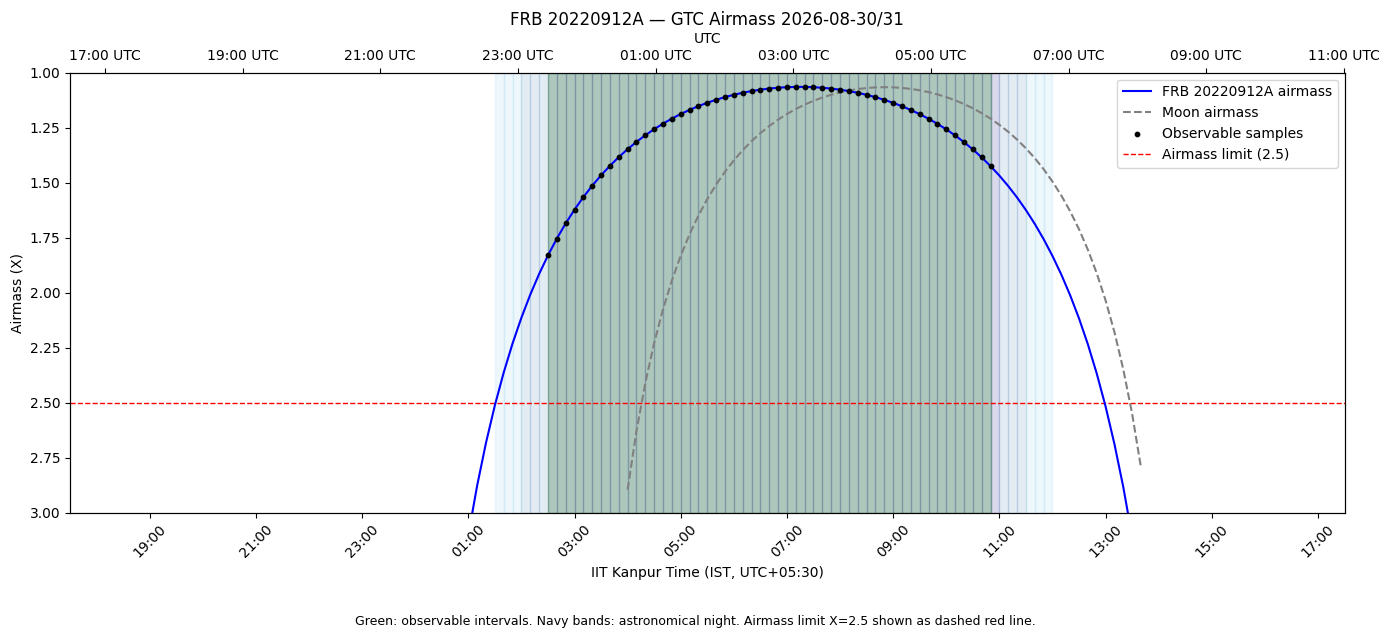

In [87]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def stitch_windows(times, visibility_state):
    windows = []
    in_win = False
    for i in range(len(times)):
        if visibility_state[i] and not in_win:
            start = i
            in_win = True
        elif not visibility_state[i] and in_win:
            end = i - 1
            windows.append((start, end))
            in_win = False
    if in_win:
        windows.append((start, len(times)-1))
    return windows
windows = stitch_windows(times, preferred_visibility)
for start, end in windows:
    mid = (start + end) // 2
    duration = (end - start + 1) * STEP_MINUTES / 60
    best_am = np.nanmin(target_airmass[start:end+1])
    print(f"Start: {format_utc(times[start])} | {format_iitk(times[start])}")
    print(f"End:   {format_utc(times[end])} | {format_iitk(times[end])}")
    print(f"Duration: {duration:.2f} hours")
    print(f"Best airmass: {best_am:.4f}")
    print(f"Moon label: {moon_labels[mid]}")
    print()
fig, ax = plt.subplots(figsize=(14, 6))
ist_times = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]
utc_times = [t.to_datetime(timezone=timezone.utc) for t in times]
for i in range(len(times)):
    if sun_alt[i] <= -18:
        ax.axvspan(ist_times[i], ist_times[min(i+1, len(times)-1)],
                   alpha=0.15, color='navy', zorder=0)
    elif sun_alt[i] <= -12:
        ax.axvspan(ist_times[i], ist_times[min(i+1, len(times)-1)],
                   alpha=0.15, color='steelblue', zorder=0)
    elif sun_alt[i] <= -6:
        ax.axvspan(ist_times[i], ist_times[min(i+1, len(times)-1)],
                   alpha=0.15, color='skyblue', zorder=0)
for start, end in windows:
    ax.axvspan(ist_times[start], ist_times[end],
               alpha=0.2, color='green', zorder=1)
ax.plot(ist_times, target_airmass,
        color='blue', linewidth=1.5, label='FRB 20220912A airmass', zorder=3)
ax.plot(ist_times, moon_airmass,
        color='gray', linewidth=1.5, linestyle='--', label='Moon airmass', zorder=3)
obs_times = [ist_times[i] for i in range(len(times)) if preferred_visibility[i]]
obs_am = [target_airmass[i] for i in range(len(times)) if preferred_visibility[i]]
ax.scatter(obs_times, obs_am, color='black', s=10, zorder=4, label='Observable samples')
ax.axhline(MAX_AIRMASS, color='red', linestyle='--', linewidth=1, label='Airmass limit (2.5)')
ax.set_ylim(3, 1)
ax.set_ylabel('Airmass (X)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=IITK_TIMEZONE))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2, tz=IITK_TIMEZONE))
ax.set_xlabel('IIT Kanpur Time (IST, UTC+05:30)')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M UTC'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2, tz=timezone.utc))
ax2.set_xlabel('UTC')
ax.set_title('FRB 20220912A — GTC Airmass 2026-08-30/31')
ax.legend(loc='upper right')
ax.set_xlim(ist_times[0], ist_times[-1])
fig.text(0.5, -0.05,
         'Green: observable intervals. Navy bands: astronomical night. '
         'Airmass limit X=2.5 shown as dashed red line.',
         ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [88]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
start1 = Time("2026-09-01T00:00:00", scale="utc")
stop1 = Time("2026-09-02T00:00:00", scale="utc")
times1 = start1 + np.arange(145) * 10 * u.min
altaz = frb_icrs.transform_to(AltAz(obstime=times1, location=gtc_location))
sun = get_sun(times1).transform_to(AltAz(obstime=times1, location=gtc_location))
am= altaz.secz.value
am[(altaz.alt.deg <= 0) | ~np.isfinite(am) | (am < 1)] = np.nan
vis = ((altaz.alt.deg > 0) &
           (np.isfinite(am) & (am <= MAX_AIRMASS)) &
           (sun.alt.deg <= MAX_SUN_ALTITUDE_DEG))
windows = stitch_windows(times, vis)
total_hours = 0
for start, end in windows:
    duration = (end - start + 1) * 10 / 60
    total_hours += duration
    print(f"Start: {format_utc(times[start])} | {format_iitk(times[start])}")
    print(f"End:   {format_utc(times[end])} | {format_iitk(times[end])}")
    print(f"Duration: {duration:.2f} hours")
    print()
print(f"Total visible duration: {total_hours:.2f} hours")

Start: 2026-08-30 12:00:00 UTC | 2026-08-30 17:30:00 IST
End:   2026-08-30 17:20:00 UTC | 2026-08-30 22:50:00 IST
Duration: 5.50 hours

Start: 2026-08-31 09:00:00 UTC | 2026-08-31 14:30:00 IST
End:   2026-08-31 12:00:00 UTC | 2026-08-31 17:30:00 IST
Duration: 3.17 hours

Total visible duration: 8.67 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
